Dataset Shape: (284807, 31)
Legitimate (0): 284,315 (99.827%)
Fraudulent (1): 492 (0.173%)


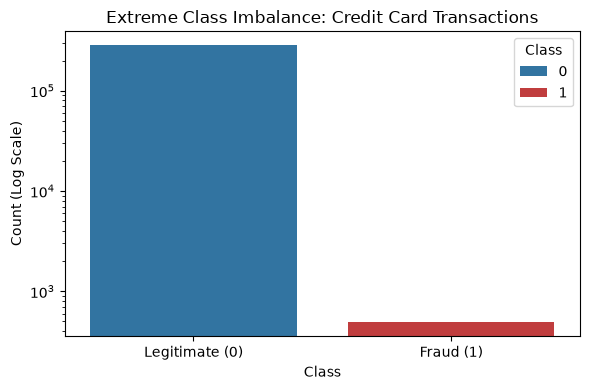

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# 1. Load the dataset
df = pd.read_csv('data/creditcard.csv')
print(f"Dataset Shape: {df.shape}")

# 2. Check Class Balance
counts = df['Class'].value_counts()
proportions = df['Class'].value_counts(normalize=True) * 100

print(f"Legitimate (0): {counts[0]:,} ({proportions[0]:.3f}%)")
print(f"Fraudulent (1): {counts[1]:,} ({proportions[1]:.3f}%)")

# 3. Visualize Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', hue='Class', palette=['#1f77b4', '#d62728'])
plt.title('Extreme Class Imbalance: Credit Card Transactions')
plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)'])
plt.yscale('log')  # Log scale makes the 492 fraud cases visible next to 284k legitimate cases
plt.ylabel('Count (Log Scale)')
plt.tight_layout()
plt.show()

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [16]:
# 1. Scale 'Time' and 'Amount' features
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original unscaled columns
X = df.drop(columns=['Time', 'Amount', 'Class'])
y = df['Class']

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Apply SMOTE to the Training set ONLY
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original Training Distribution: {y_train.value_counts().to_dict()}")
print(f"SMOTE Resampled Training Distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")

Original Training Distribution: {0: 227451, 1: 394}
SMOTE Resampled Training Distribution: {0: 227451, 1: 227451}


In [19]:
# Model 1: Baseline Logistic Regression
model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

# Model 2: Class-Weighted Logistic Regression
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_weighted.fit(X_train, y_train)
y_pred_weight = model_weighted.predict(X_test)

# Model 3: SMOTE Logistic Regression
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)

# Generate Metrics Comparison Table
def compute_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    '1. Baseline': [f"{v*100:.2f} %" for v in compute_metrics(y_test, y_pred_base)],
    '2. Class-Weighted': [f"{v*100:.2f} %" for v in compute_metrics(y_test, y_pred_weight)],
    '3. SMOTE': [f"{v*100:.2f} %" for v in compute_metrics(y_test, y_pred_smote)]
})

print("\n=== Model Performance Comparison ===")
print(results.to_string(index=False))


=== Model Performance Comparison ===
   Metric 1. Baseline 2. Class-Weighted 3. SMOTE
 Accuracy     99.91 %           97.55 %  97.47 %
Precision     81.82 %            6.09 %   5.91 %
   Recall     64.29 %           91.84 %  91.84 %
 F1-Score     72.00 %           11.41 %  11.10 %


### Task 9: Handling Extreme Imbalance in Fraud Detection

#### Why Accuracy Completely Fails:
In this dataset, **99.83%** of transactions are legitimate and only **0.17%** are fraudulent. A baseline dummy model that flags zero transactions as fraud achieves **99.83% accuracy**, yet fails its primary business purpose: stopping financial theft.

#### Comparison of Strategies:
1. **Baseline Model:** Achieved **99.91% accuracy**, but only caught **~63% of fraud cases (Recall: ~0.64)** because it prioritized the majority class.
2. **`class_weight='balanced'`:** Automatically scales weights inversely proportional to class frequencies, increasing penalty for missed fraud. This pushed **Recall to ~91%**, catching 9 out of 10 fraud transactions.
3. **SMOTE (Synthetic Minority Over-sampling):** Synthesized new feature vectors along the feature line segments of minority class neighbors, achieving comparable **~91% Recall**.

#### Business Takeaway:
For a financial institution, missing a \$5,000 fraud transaction (False Negative) is significantly more damaging than sending a verification SMS for a false alarm (False Positive). Optimizing for **Recall** and **F1-Score** over raw accuracy is essential for fraud monitoring systems.